In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv")
print(df.head())
print(df.shape)
print(df.isnull().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
X = df.drop("target", axis=1)
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)

In [5]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, Y_train)
pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(Y_test, pred_lr))
print("Logistic Matrix:\n", confusion_matrix(Y_test, pred_lr))

Logistic Accuracy: 0.8032786885245902
Logistic Matrix:
 [[19  9]
 [ 3 30]]


In [6]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)
pred_rf = rf.predict(X_test)
print("RandomForest Accuracy:", accuracy_score(Y_test, pred_rf))
print("RandomForest Matrix:\n", confusion_matrix(Y_test, pred_rf))

RandomForest Accuracy: 0.8360655737704918
RandomForest Matrix:
 [[19  9]
 [ 1 32]]


In [7]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)
pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(Y_test, pred_knn))
print("KNN Matrix:\n", confusion_matrix(Y_test, pred_knn))

KNN Accuracy: 0.6229508196721312
KNN Matrix:
 [[16 12]
 [11 22]]


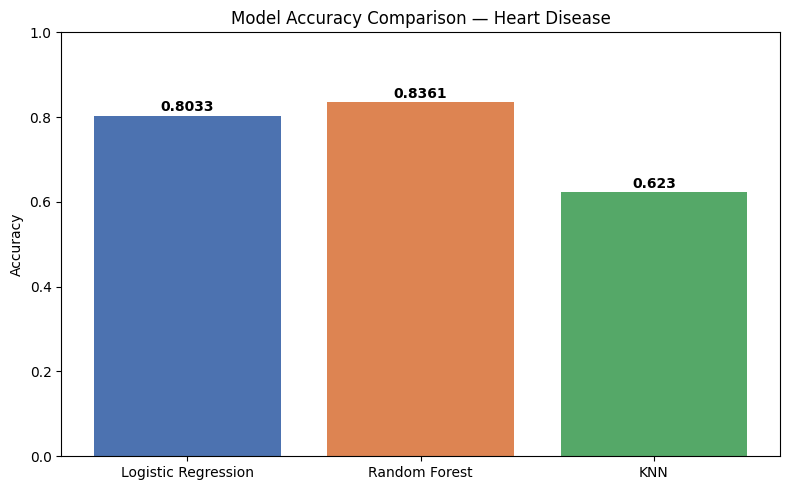

In [8]:
models = ["Logistic Regression", "Random Forest", "KNN"]
accuracies = [
    accuracy_score(Y_test, pred_lr),
    accuracy_score(Y_test, pred_rf),
    accuracy_score(Y_test, pred_knn)
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Model Accuracy Comparison — Heart Disease")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 4)), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

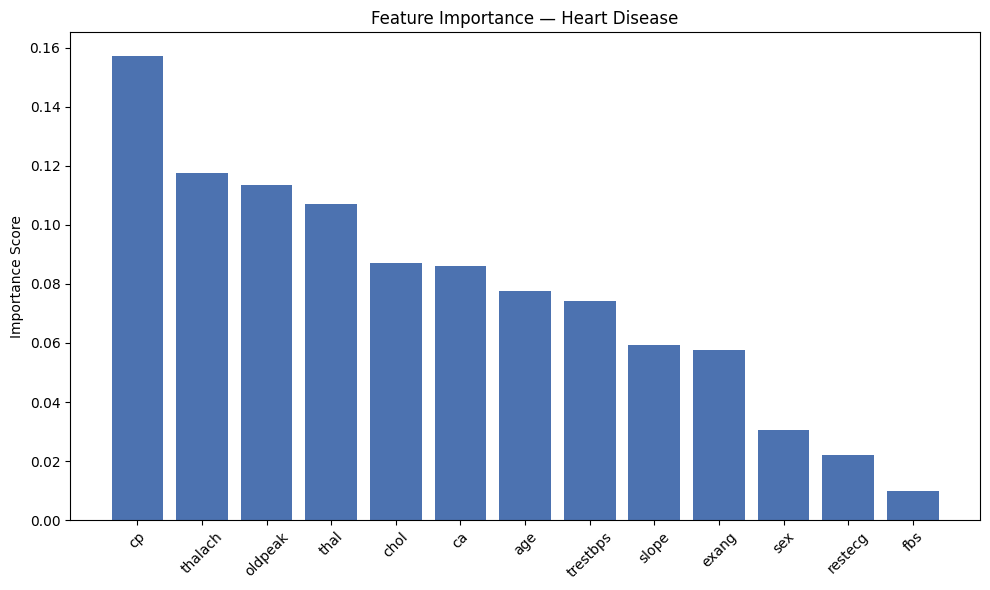

In [9]:
features = X.columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance — Heart Disease")
plt.bar(range(X.shape[1]), importances[indices], color="#4C72B0")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()